Pandas

In [58]:
import pandas as pd

 load the .csv file as a dataframe using pandas:

In [59]:
police_data = pd.read_csv("./data/police.csv")
police_data


,stop_date,stop_time,county_name,driver_gender,driver_age_raw,driver_age,driver_race,violation_raw,violation,search_conducted,search_type,stop_outcome,is_arrested,stop_duration,drugs_related_stop
0,2005-01-02,01:55,NaN,M,1985.0,20.0,White,Speeding,Speeding,False,NaN,Citation,False,0-15 Min,False
1,2005-01-18,08:15,NaN,M,1965.0,40.0,White,Speeding,Speeding,False,NaN,Citation,False,0-15 Min,False
2,2005-01-23,23:15,NaN,M,1972.0,33.0,White,Speeding,Speeding,False,NaN,Citation,False,0-15 Min,False
3,2005-02-20,17:15,NaN,M,1986.0,19.0,White,Call for Service,Other,False,NaN,Arrest Driver,True,16-30 Min,False
4,2005-03-14,10:00,NaN,F,1984.0,21.0,White,Speeding,Speeding,False,NaN,Citation,False,0-15 Min,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91736,2015-12-31,20:27,NaN,M,1986.0,29.0,White,Speeding,Speeding,False,NaN,Warning,False,0-15 Min,False
91737,2015-12-31,20:35,NaN,F,1982.0,33.0,White,Equipment/Inspection Violation,Equipment,False,NaN,Warning,False,0-15 Min,False
91738,2015-12-31,20:45,NaN,M,1992.0,23.0,White,Other Traffic Violation,Moving violation,False,NaN,Warning,False,0-15 Min,False
91739,2015-12-31,21:42,NaN,M,1993.0,22.0,White,Speeding,Speeding,False,NaN,Citation,False,0-15 Min,False


Get familiar with the read data

In [60]:
print(police_data.columns)

Index(['stop_date', 'stop_time', 'county_name', 'driver_gender',
       'driver_age_raw', 'driver_age', 'driver_race', 'violation_raw',
       'violation', 'search_conducted', 'search_type', 'stop_outcome',
       'is_arrested', 'stop_duration', 'drugs_related_stop'],
      dtype='object')


In [61]:
police_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91741 entries, 0 to 91740
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   stop_date           91741 non-null  object 
 1   stop_time           91741 non-null  object 
 2   county_name         0 non-null      float64
 3   driver_gender       86406 non-null  object 
 4   driver_age_raw      86414 non-null  float64
 5   driver_age          86120 non-null  float64
 6   driver_race         86408 non-null  object 
 7   violation_raw       86408 non-null  object 
 8   violation           86408 non-null  object 
 9   search_conducted    91741 non-null  bool   
 10  search_type         3196 non-null   object 
 11  stop_outcome        86408 non-null  object 
 12  is_arrested         86408 non-null  object 
 13  stop_duration       86408 non-null  object 
 14  drugs_related_stop  91741 non-null  bool   
dtypes: bool(2), float64(3), object(10)
memory usage: 9.3+

Cleaning dataset

0 non-empty values (all rows are empty) for the country_name variable. This shows that none of the stops has the information about the county where it was made. In addition, the search_type column also has a lot of missing information - only 3196 of the 91741 rows (observations) are completed. The two variables mentioned above do not carry much information, so we will drop them from the dataset:

In [62]:
police_data = police_data.drop(columns=["county_name", "search_type"], axis=1)


The column that has the most empty values still has a high completion (93.9% of the values are non-empty). Therefore, we will remove all rows that have at least one empty value.

In [63]:
police_data.dropna(inplace=True)

Looking at the result of the .info() method called on our data frame, we see that many of the columns have the "object" type. "object" is the default data type in pandas, if the library was unable to properly recognize the type when loading the data frame. Looking at the values of the variables, you can see that we have three columns that store True/False values, that is, they are of type bool. Using the code below, we can change the data type in these columns:

In [64]:
boolean_columns = ["search_conducted", "is_arrested", "drugs_related_stop"]
for column in boolean_columns:
  police_data[column] = police_data[column].astype("bool")


In our dataset, we have the stopped drivers' year of birth (driver_age_raw) and their age at the time of the stop (driver_age). Based on this, we can count the year of the stop. In Pandas, we can do this similarly to adding two numbers in pure Python:

In [65]:
police_data["stop_year"] = police_data["driver_age_raw"] + police_data["driver_age"]
police_data

,stop_date,stop_time,driver_gender,driver_age_raw,driver_age,driver_race,violation_raw,violation,search_conducted,stop_outcome,is_arrested,stop_duration,drugs_related_stop,stop_year
0,2005-01-02,01:55,M,1985.0,20.0,White,Speeding,Speeding,False,Citation,False,0-15 Min,False,2005.0
1,2005-01-18,08:15,M,1965.0,40.0,White,Speeding,Speeding,False,Citation,False,0-15 Min,False,2005.0
2,2005-01-23,23:15,M,1972.0,33.0,White,Speeding,Speeding,False,Citation,False,0-15 Min,False,2005.0
3,2005-02-20,17:15,M,1986.0,19.0,White,Call for Service,Other,False,Arrest Driver,True,16-30 Min,False,2005.0
4,2005-03-14,10:00,F,1984.0,21.0,White,Speeding,Speeding,False,Citation,False,0-15 Min,False,2005.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91736,2015-12-31,20:27,M,1986.0,29.0,White,Speeding,Speeding,False,Warning,False,0-15 Min,False,2015.0
91737,2015-12-31,20:35,F,1982.0,33.0,White,Equipment/Inspection Violation,Equipment,False,Warning,False,0-15 Min,False,2015.0
91738,2015-12-31,20:45,M,1992.0,23.0,White,Other Traffic Violation,Moving violation,False,Warning,False,0-15 Min,False,2015.0
91739,2015-12-31,21:42,M,1993.0,22.0,White,Speeding,Speeding,False,Citation,False,0-15 Min,False,2015.0


Filter cleaned dataset

In [66]:
police_data[(police_data["driver_gender"] == "M")]


,stop_date,stop_time,driver_gender,driver_age_raw,driver_age,driver_race,violation_raw,violation,search_conducted,stop_outcome,is_arrested,stop_duration,drugs_related_stop,stop_year
0,2005-01-02,01:55,M,1985.0,20.0,White,Speeding,Speeding,False,Citation,False,0-15 Min,False,2005.0
1,2005-01-18,08:15,M,1965.0,40.0,White,Speeding,Speeding,False,Citation,False,0-15 Min,False,2005.0
2,2005-01-23,23:15,M,1972.0,33.0,White,Speeding,Speeding,False,Citation,False,0-15 Min,False,2005.0
3,2005-02-20,17:15,M,1986.0,19.0,White,Call for Service,Other,False,Arrest Driver,True,16-30 Min,False,2005.0
5,2005-03-23,09:45,M,1982.0,23.0,Black,Equipment/Inspection Violation,Equipment,False,Citation,False,0-15 Min,False,2005.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91735,2015-12-31,20:25,M,1992.0,23.0,Hispanic,Speeding,Speeding,False,Citation,False,0-15 Min,False,2015.0
91736,2015-12-31,20:27,M,1986.0,29.0,White,Speeding,Speeding,False,Warning,False,0-15 Min,False,2015.0
91738,2015-12-31,20:45,M,1992.0,23.0,White,Other Traffic Violation,Moving violation,False,Warning,False,0-15 Min,False,2015.0
91739,2015-12-31,21:42,M,1993.0,22.0,White,Speeding,Speeding,False,Citation,False,0-15 Min,False,2015.0


Combine filter criteria 

In [67]:
police_data[(police_data["driver_gender"] == "M") & (police_data["driver_age"] > 25)]


,stop_date,stop_time,driver_gender,driver_age_raw,driver_age,driver_race,violation_raw,violation,search_conducted,stop_outcome,is_arrested,stop_duration,drugs_related_stop,stop_year
1,2005-01-18,08:15,M,1965.0,40.0,White,Speeding,Speeding,False,Citation,False,0-15 Min,False,2005.0
2,2005-01-23,23:15,M,1972.0,33.0,White,Speeding,Speeding,False,Citation,False,0-15 Min,False,2005.0
6,2005-04-01,17:30,M,1969.0,36.0,White,Speeding,Speeding,False,Citation,False,0-15 Min,False,2005.0
8,2005-07-13,10:15,M,1970.0,35.0,Black,Speeding,Speeding,False,Citation,False,0-15 Min,False,2005.0
9,2005-07-13,15:45,M,1970.0,35.0,White,Speeding,Speeding,False,Citation,False,0-15 Min,False,2005.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91721,2015-12-31,06:49,M,1943.0,72.0,White,Speeding,Speeding,False,Warning,False,0-15 Min,False,2015.0
91722,2015-12-31,07:06,M,1970.0,45.0,Black,Speeding,Speeding,False,Citation,False,0-15 Min,False,2015.0
91723,2015-12-31,07:14,M,1978.0,37.0,Hispanic,Registration Violation,Registration/plates,False,Citation,False,0-15 Min,False,2015.0
91736,2015-12-31,20:27,M,1986.0,29.0,White,Speeding,Speeding,False,Warning,False,0-15 Min,False,2015.0


In [68]:
police_data[(police_data["driver_gender"] == "M") | (police_data["driver_age"] > 25)]


,stop_date,stop_time,driver_gender,driver_age_raw,driver_age,driver_race,violation_raw,violation,search_conducted,stop_outcome,is_arrested,stop_duration,drugs_related_stop,stop_year
0,2005-01-02,01:55,M,1985.0,20.0,White,Speeding,Speeding,False,Citation,False,0-15 Min,False,2005.0
1,2005-01-18,08:15,M,1965.0,40.0,White,Speeding,Speeding,False,Citation,False,0-15 Min,False,2005.0
2,2005-01-23,23:15,M,1972.0,33.0,White,Speeding,Speeding,False,Citation,False,0-15 Min,False,2005.0
3,2005-02-20,17:15,M,1986.0,19.0,White,Call for Service,Other,False,Arrest Driver,True,16-30 Min,False,2005.0
5,2005-03-23,09:45,M,1982.0,23.0,Black,Equipment/Inspection Violation,Equipment,False,Citation,False,0-15 Min,False,2005.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91736,2015-12-31,20:27,M,1986.0,29.0,White,Speeding,Speeding,False,Warning,False,0-15 Min,False,2015.0
91737,2015-12-31,20:35,F,1982.0,33.0,White,Equipment/Inspection Violation,Equipment,False,Warning,False,0-15 Min,False,2015.0
91738,2015-12-31,20:45,M,1992.0,23.0,White,Other Traffic Violation,Moving violation,False,Warning,False,0-15 Min,False,2015.0
91739,2015-12-31,21:42,M,1993.0,22.0,White,Speeding,Speeding,False,Citation,False,0-15 Min,False,2015.0


Normalize data (text data)
We can see that the data in this column are text strings. In this type of data, there may be errors (e.g. typos) or values that are not unified (e.g. they start with a capital letter in one case and a lowercase letter in another.



In [69]:
police_data["violation_raw"] = police_data["violation_raw"].str.lower().str.strip()


Checking for duplicates

In [70]:
print(police_data["violation_raw"].unique())


['speeding' 'call for service' 'equipment/inspection violation'
 'other traffic violation' 'registration violation'
 'special detail/directed patrol' 'apb' 'violation of city/town ordinance'
 'suspicious person' 'motorist assist/courtesy' 'warrant'
 'seatbelt violation']


If there are typos, we could use the .replace() method, by which we would replace the incorrect values with the correct ones. It could look like this:

In [71]:
police_data["violation_raw"] = police_data["violation_raw"].replace({"speding": "speeding"})


 we have a normalized list of violations. Let's see how many violations of each type we have:

In [72]:
violation_count = police_data['violation_raw'].value_counts()
violation_count

violation_raw
speeding                            48359
other traffic violation             16164
equipment/inspection violation      11007
registration violation               3427
seatbelt violation                   2952
special detail/directed patrol       2369
call for service                     1288
violation of city/town ordinance      211
motorist assist/courtesy              189
apb                                    78
suspicious person                      54
warrant                                15
Name: count, dtype: int64

Group by gender

In [73]:
violation_count_by_sex = police_data.groupby(['violation_raw', 'driver_gender'], as_index=False).size().sort_values(by=["driver_gender", "size"], ascending=False)
violation_count_by_sex


,violation_raw,driver_gender,size
17,speeding,M,32906
9,other traffic violation,M,12969
5,equipment/inspection violation,M,8523
11,registration violation,M,2415
13,seatbelt violation,M,2317
15,special detail/directed patrol,M,2262
3,call for service,M,855
21,violation of city/town ordinance,M,165
7,motorist assist/courtesy,M,130
1,apb,M,57


In [74]:
mean_age = police_data[["driver_age", "driver_gender"]].groupby(["driver_gender"]).agg({"driver_age": "mean"})
mean_age


,driver_age
driver_gender,
F,32.607399
M,34.537886


Matplotlib
From our dataset, we can make helpful visualizations to help us interpret our data quickly and effectively. Pandas has good integration with the matplotlib library. We can make charts by calling the .plot() method directly on the data frame. First, let's visualize the number of violations by type:

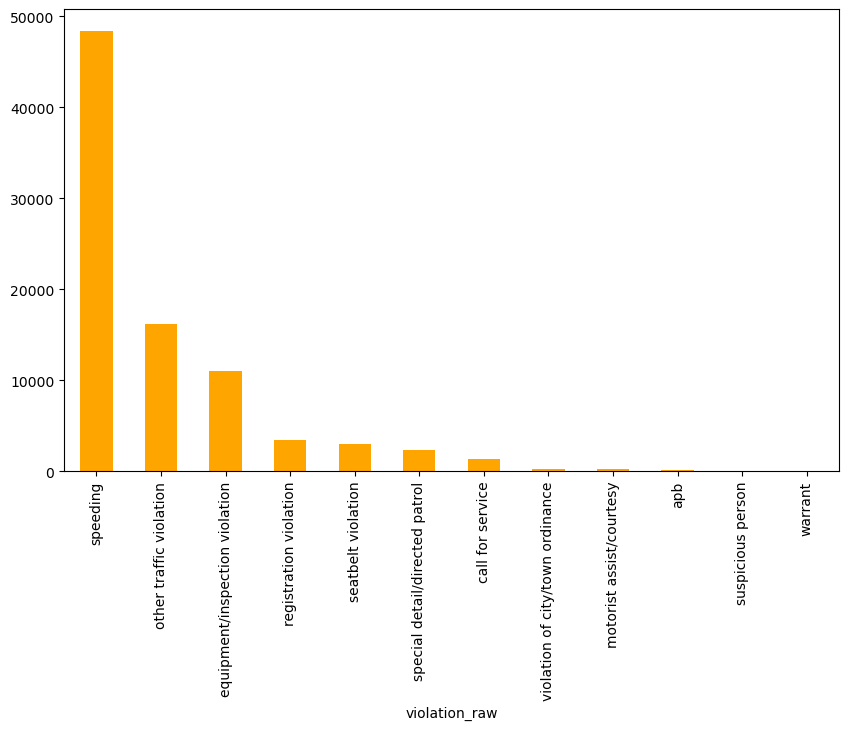

In [75]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
violation_graph = police_data["violation_raw"].value_counts().plot(kind="bar", color="orange")
plt.show()

the number of violations increases over time:

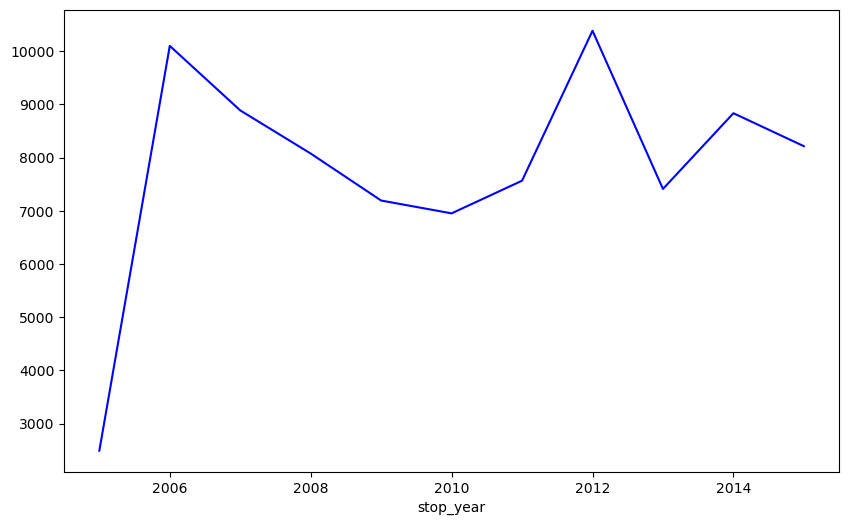

In [76]:
plt.figure(figsize=(10, 6))

stop_count_by_year = police_data["stop_year"].astype("int").value_counts().sort_index()
stop_count_by_year_graph = stop_count_by_year.plot(kind="line", color="blue")


We also have the option to generate other visualizations than the common column or line charts. Let's see what the age of men and women who were stopped looks like from a statistical perspective. Initially, we need to filter the data by gender, and then create a new DataFrame from two Series objects (a Series is a single column from a DataFrame). Then using the new DataFrame, we can apply two different box plots to one figure object:

<Axes: >

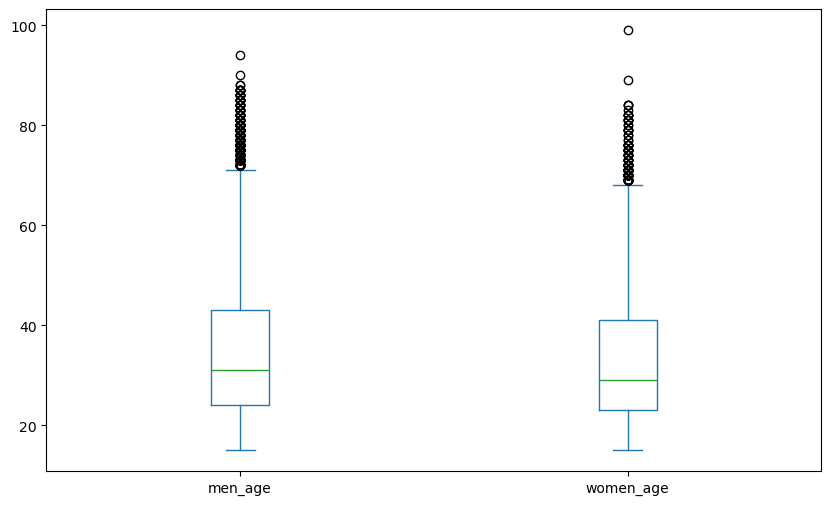

In [77]:
# create two Series objects for both gender data
men_age_data = police_data[police_data["driver_gender"] == "M"]["driver_age"]
women_age_data = police_data[police_data["driver_gender"] == "F"]["driver_age"]

# create DataFrame based on created Series objects
age_data = pd.DataFrame({"men_age": men_age_data, "women_age": women_age_data})

# adjust figure size for figure that have two plots
plt.rcParams["figure.figsize"] = [10, 6]
# plot two box plots: showing men and women age statistics
age_data.plot(kind="box")

Plotly

Matplotlib allows us to quickly create basic static visualizations. These types of visualizations are good when we are working on some analysis and want to quickly check selected relationships and the charts are only for us. When we need to show the graphs to a wider audience, that's when it's a good idea to make interactive visualizations that are a bit more aesthetically pleasing and easier to interpret. In Python, we can use the plotly library, which we learned about in the "Data Visualization" course.

Let's recall how we can make a column chart. Suppose we want to look at the number of violation by stop outcome:

In [80]:
import plotly.express as px

stop_outcome_count = (
    police_data["stop_outcome"]
    .value_counts()
    .rename_axis("stop_outcome")
    .reset_index(name="count")
)

stop_outcome_plot = px.bar(
    stop_outcome_count,
    x="stop_outcome",
    y="count",
    title="Number of Stops by Outcome"
)

stop_outcome_plot.show()

Let's generate another chart using our dataset. Let's check how many violations were committed by drivers in December 2015, broken down by race (driver_race). To do this, we will filter the data and then count the occurrences for the pair of variables stop_date and driver_race. We will also perform the reset_index operation because using the value_counts() method results in changing the DataFrame to Series. After performing this operation, we will sort the values against stop_date and rename the columns to better describe the data in our DataFrame. Finally, we will create a graph so that there are as many lines on the graph as there are races, which will show the number of violations over time for each of them.

In [83]:
stop_outcome_by_race = police_data[["stop_date", "driver_race"]].value_counts().reset_index().rename(columns={0: "count"}).sort_values(by="stop_date")
stop_outcome_by_race_plot = px.line(data_frame=stop_outcome_by_race[stop_outcome_by_race["stop_date"] > "2015-12-01"],
                                    x="stop_date",
                                    y="count",
                                    color="driver_race")
stop_outcome_by_race_plot.show()


We will revise two more charts that are not particularly applicable to the dataset we have been working on. So let's create a simple set consisting of 4 numeric variables: A, B, C, D:

In [82]:
# import necessary libraries
import pandas as pd
import plotly.express as px

# example data
data = {
    'A': [10, 20, 30, 40, 50, 55, 62, 87, 90],
    'B': [100, 120, 150, 60, 70, 42, 45, 79, 2],
    'C': [12, 40, 65, 15, 24, 11, 27, 74, 12],
    'D': [50, 93, 20, -5, 110, -12, -30, 45, 5]
}


The dictionary with the numeric data stored in the data variable will be used to create a data frame, and then calculate the correlation matrix between the variables. Here we will use Pearson correlation (which, by the way, is the default for the .corr() method), which we have already encountered during the Data Lab track.

In [84]:
# create dataframe
df = pd.DataFrame(data)

# calculate correlation matrix
correlation_matrix = df.corr(method="pearson")

Finally, we can use the imshow() method to which we will pass our data frame, set the chart title and include labels for each square in the correlation matrix, which will show the value of the correlation between one variable and another. By passing the value of True to the text_auto argument, we would make it display the number without rounding. To round the number and thus improve the readability of the chart we will use the .xf notation, where x is the number of decimal places:

In [85]:
# correlation matrix plot
fig = px.imshow(correlation_matrix,
                x=correlation_matrix.columns,
                y=correlation_matrix.index,
                title="Correlation matrix",
                text_auto=".4f")

# show plot
fig.show()

Based on our original data frame df, we can create a scatter plot for the variables "A" and "B", which will show the relationship between the two variables. The scatter plot in Plotly is created very simply, using the .scatter() method.

In [87]:
scatter_plot = px.scatter(data_frame=df, x="A", y="B")
scatter_plot.show()

NumPy
Finally, we are left with the NumPy library, which is used to perform numerical calculations, including working with multidimensional arrays, matrices, and mathematical functions. To create an array using NumPy, use the .array() method:

In [93]:
import numpy as np

# create array
arr = np.array([1, 2, 3, 4, 5])
arr

array([1, 2, 3, 4, 5])

In [95]:
# Creating a 2D array (matrix)
matrix = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])
matrix

array([[1, 2, 3],
       [4, 5, 6],
       [7, 8, 9]])

In [97]:
# create array with given size with 0s
zeros_np = np.zeros((3, 3))
# create array with given size with 1s
ones_np = np.ones((3, 3))
print(zeros_np)
print(ones_np)

[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]
[[1. 1. 1.]
 [1. 1. 1.]
 [1. 1. 1.]]


In [99]:
# create an array with evenly spaced values in a specified range
evenly_array = np.linspace(0, 10, 5)
print(evenly_array)
# array with random values
random_array = np.random.rand(3, 3)
print(random_array)

[ 0.   2.5  5.   7.5 10. ]
[[0.75636178 0.55336683 0.78787735]
 [0.1301505  0.30049465 0.32858067]
 [0.36164037 0.20986481 0.80311038]]


In [101]:
# math functions
sin_arr = np.sin(arr)
sqrt_arr = np.sqrt(arr)
sum_arr= np.sum(arr)

print(sin_arr)
print(sqrt_arr)
print(sum_arr)

[ 0.84147098  0.90929743  0.14112001 -0.7568025  -0.95892427]
[1.         1.41421356 1.73205081 2.         2.23606798]
15


In [102]:
# matrix operations
multiplied_matrix = np.dot(matrix, ones_np)  # matrix multiplying
transposed_matrix = np.transpose(matrix)  # matrix transpose

print(multiplied_matrix)
print(transposed_matrix)

[[ 6.  6.  6.]
 [15. 15. 15.]
 [24. 24. 24.]]
[[1 4 7]
 [2 5 8]
 [3 6 9]]


In [103]:
# indexing and slicing
arr_sliced = arr[2:4]  # slice "a" array from index 2 to 4 (without 4)
matrix_sliced = matrix[:, 1]  # slice second column from matrix

print(arr_sliced)
print(matrix_sliced)

[3 4]
[2 5 8]


In [104]:
# reshape array
reshaped_arr = arr.reshape(1, -1)  # transform "arr" array to matrix with one-row
reshaped_arr

array([[1, 2, 3, 4, 5]])